# 데이터 품질 검증 (Data Quality Check)

## 목표
합성 데이터의 품질 문제를 체계적으로 찾아내고 분석합니다.

## 검증 항목
1. 결측치 분석
2. 데이터 타입 검증
3. 값 범위 검증 (음수가 나오면 안 되는 컬럼)
4. 중복값/반복값 분석
5. 이상치 탐지
6. 논리적 일관성 검증 (재무 공식)
7. 통계적 분포 확인
8. 데이터 품질 리포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# 데이터 로드
df = pd.read_csv('../data/기업신용평가정보_합성데이터.csv', encoding='cp949')
print(f"데이터 shape: {df.shape}")
print(f"총 행 수: {len(df):,}")

데이터 shape: (600000, 159)
총 행 수: 600,000


## 1. 결측치 분석

In [3]:
# 결측치 비율 계산
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    '결측수': missing,
    '비율(%)': missing_pct
}).sort_values('비율(%)', ascending=False)

missing_df = missing_df[missing_df['결측수'] > 0]

print(f"결측치가 있는 컬럼 수: {len(missing_df)}")
print(f"\n결측치 비율 상위 20개:")
print(missing_df.head(20))

결측치가 있는 컬럼 수: 13

결측치 비율 상위 20개:
                 결측수  비율(%)
상장폐지일자        599596  99.93
상장일자          577945  96.32
재무비율_총자산순이익률  378251  63.04
재무비율_당기순이익율   374613  62.44
주소지시군구         49008   8.17
재무비율_유형자산증가율   45305   7.55
재무비율_매입채무회전율   45305   7.55
재무비율_유동자산증가율   45305   7.55
부채상환계수.1       38988   6.50
EBITDA증가율      23856   3.98
영업이익이자보상배율       313   0.05
이자보상배율           313   0.05
업종(중분류)           58   0.01


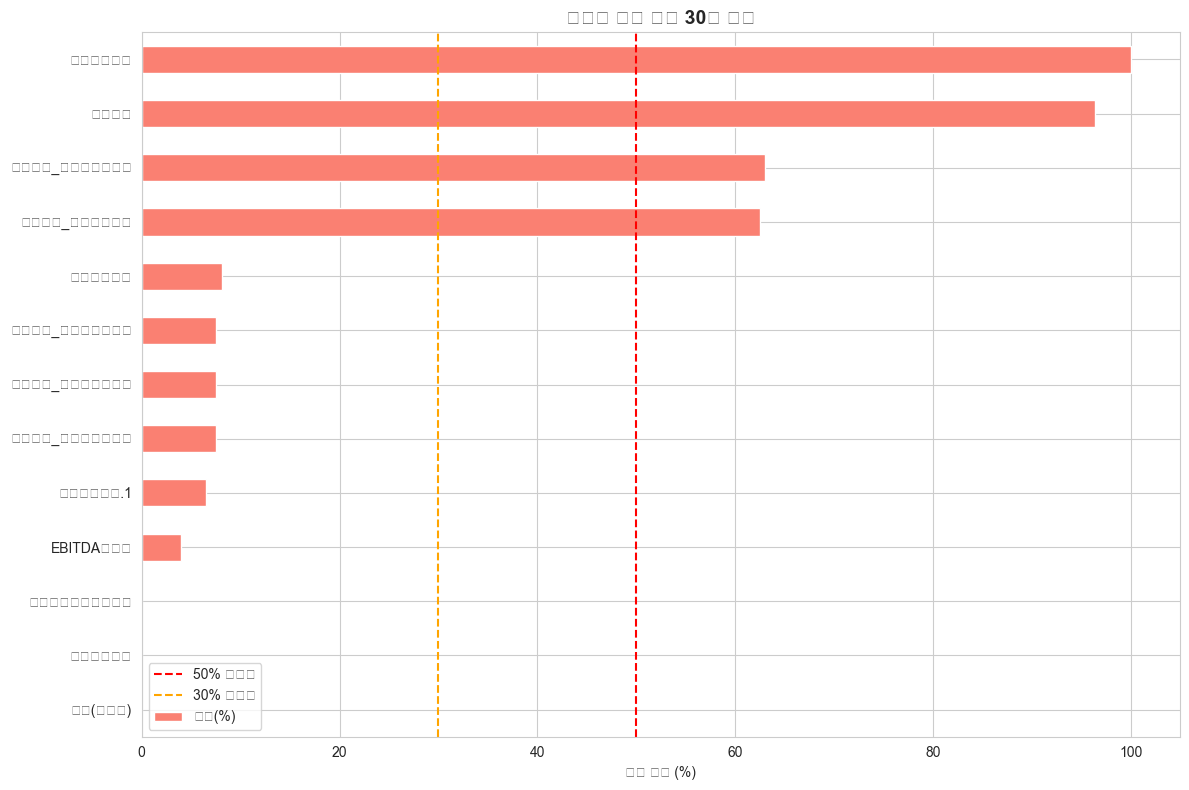


🚨 결측치 50% 이상 컬럼: 4개
⚠️ 결측치 30-50% 컬럼: 0개
✅ 결측치 30% 미만 컬럼: 9개


In [4]:
# 결측치 비율 시각화
plt.figure(figsize=(12, 8))
missing_df.head(30)['비율(%)'].plot(kind='barh', color='salmon')
plt.title('결측치 비율 상위 30개 컬럼', fontsize=14, fontweight='bold')
plt.xlabel('결측 비율 (%)')
plt.gca().invert_yaxis()
plt.axvline(x=50, color='red', linestyle='--', label='50% 기준선')
plt.axvline(x=30, color='orange', linestyle='--', label='30% 기준선')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n🚨 결측치 50% 이상 컬럼: {(missing_df['비율(%)'] >= 50).sum()}개")
print(f"⚠️ 결측치 30-50% 컬럼: {((missing_df['비율(%)'] >= 30) & (missing_df['비율(%)'] < 50)).sum()}개")
print(f"✅ 결측치 30% 미만 컬럼: {(missing_df['비율(%)'] < 30).sum()}개")

## 2. 데이터 타입 검증

In [5]:
# 데이터 타입별 컬럼 수
print("=== 데이터 타입 분포 ===")
print(df.dtypes.value_counts())

# 숫자형 컬럼 목록
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n숫자형 컬럼 수: {len(numeric_cols)}")

# 문자형 컬럼 목록
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"문자형 컬럼 수: {len(object_cols)}")
print(f"\n문자형 컬럼 목록:")
for col in object_cols:
    print(f"  - {col}")

=== 데이터 타입 분포 ===
int64      97
float64    61
object      1
Name: count, dtype: int64

숫자형 컬럼 수: 158
문자형 컬럼 수: 1

문자형 컬럼 목록:
  - 업종(중분류)


## 3. 값 범위 검증 (음수가 나오면 안 되는 컬럼)

재무 데이터에서 음수가 나오면 안 되는 컬럼들을 검증합니다.

In [6]:
# 음수가 나오면 안 되는 컬럼 정의
non_negative_cols = [
    '유동자산', '비유동자산', '총자산', '당좌자산', '재고자산', '유형자산',
    '매출채권', '매출액', '종업원수',
    # 비율 컬럼 중 일부는 음수 가능 (손실 등)
]

# 실제로 존재하는 컬럼만 필터링
non_negative_cols = [col for col in non_negative_cols if col in df.columns]

print("=== 음수 값 검증 ===")
negative_issues = {}

for col in non_negative_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        negative_pct = (negative_count / len(df) * 100).round(2)
        negative_issues[col] = {
            '음수 개수': negative_count,
            '비율(%)': negative_pct,
            '최솟값': df[col].min()
        }

if negative_issues:
    negative_df = pd.DataFrame(negative_issues).T
    print(f"\n🚨 음수가 발견된 컬럼: {len(negative_issues)}개")
    print(negative_df.sort_values('비율(%)', ascending=False))
else:
    print("✅ 모든 컬럼에서 음수 값 없음")

=== 음수 값 검증 ===

🚨 음수가 발견된 컬럼: 7개
       음수 개수  비율(%)          최솟값
매출액    303.0   0.05  -14445658.0
비유동자산  157.0   0.03 -188577936.0
유동자산    35.0   0.01    -908702.0
당좌자산    45.0   0.01    -908702.0
유형자산    83.0   0.01   -6323838.0
매출채권    61.0   0.01    -522238.0
재고자산    19.0   0.00    -300642.0


In [7]:
# 0 값 검증 (일부 컬럼은 0이면 문제)
should_not_be_zero = ['총자산', '매출액']  # 총자산과 매출액이 0이면 이상함
should_not_be_zero = [col for col in should_not_be_zero if col in df.columns]

print("\n=== 0 값 검증 ===")
zero_issues = {}

for col in should_not_be_zero:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        zero_pct = (zero_count / len(df) * 100).round(2)
        zero_issues[col] = {
            '0 개수': zero_count,
            '비율(%)': zero_pct
        }

if zero_issues:
    zero_df = pd.DataFrame(zero_issues).T
    print(f"\n⚠️ 0 값이 발견된 컬럼:")
    print(zero_df)
else:
    print("✅ 모든 컬럼에서 0 값 문제 없음")


=== 0 값 검증 ===

⚠️ 0 값이 발견된 컬럼:
       0 개수  비율(%)
매출액  4889.0   0.81


## 4. 중복값/반복값 분석

특정 값이 비정상적으로 많이 반복되는지 확인합니다.

In [8]:
# 숫자형 컬럼에서 가장 빈도가 높은 값 찾기
print("=== 반복값이 많은 숫자형 컬럼 (상위 20개) ===")

repetition_analysis = {}

for col in numeric_cols:
    if df[col].notna().sum() == 0:  # 모두 결측치면 skip
        continue
    
    value_counts = df[col].value_counts()
    if len(value_counts) > 0:
        most_common_value = value_counts.index[0]
        most_common_count = value_counts.iloc[0]
        most_common_pct = (most_common_count / df[col].notna().sum() * 100).round(2)
        
        # 고유값 개수
        unique_count = df[col].nunique()
        
        repetition_analysis[col] = {
            '최빈값': most_common_value,
            '최빈값 개수': most_common_count,
            '최빈값 비율(%)': most_common_pct,
            '고유값 개수': unique_count
        }

rep_df = pd.DataFrame(repetition_analysis).T.sort_values('최빈값 비율(%)', ascending=False)
print(rep_df.head(20))

=== 반복값이 많은 숫자형 컬럼 (상위 20개) ===
                                          최빈값    최빈값 개수  최빈값 비율(%)  고유값 개수
사채이자(당기)                                  0.0  599910.0      99.98    30.0
기업신용공여30일이상연체기관수(일보)(이자연체)(미해제)           0.0  599268.0      99.88     6.0
기업신용공여30일이상연체과목수(일보)(이자연체)(미해제)           0.0  599270.0      99.88    10.0
기업신용공여30일이상연체기관수(일보)(미해제)                 0.0  598949.0      99.82     9.0
기업신용공여30일이상연체과목수(일보)(미해제)                 0.0  598949.0      99.82    14.0
기업신용공여연체기관수(일보)(3개월내유지)(연체일수30일이상)(해제포함)  0.0  598184.0      99.70     8.0
기업신용공여연체과목수(일보)(3개월내유지)(연체일수30일이상)(해제포함)  0.0  598184.0      99.70    13.0
현금등가물                                     0.0  598091.0      99.68   938.0
기업신용공여연체기관수(일보)(6개월내유지)(연체일수30일이상)(해제포함)  0.0  596838.0      99.47     7.0
기업신용공여연체과목수(일보)(6개월내유지)(연체일수30일이상)(해제포함)  0.0  596838.0      99.47    16.0
공공정보(국세,지방세,관세체납)건수(CIS)(5년내발생)           0.0  596548.0      99.42    14.0
공공정보(국세,지방세,관세체납)건수(CIS)(미해제)             0.0  596532.0      99.42  

In [9]:
# 의심스러운 반복값 (80% 이상 동일한 값)
suspicious_repetition = rep_df[rep_df['최빈값 비율(%)'] >= 80]

if len(suspicious_repetition) > 0:
    print(f"\n🚨 비정상적인 반복값 (80% 이상): {len(suspicious_repetition)}개")
    print(suspicious_repetition)
else:
    print("\n✅ 비정상적인 반복값 없음")


🚨 비정상적인 반복값 (80% 이상): 57개
                                                  최빈값    최빈값 개수  최빈값 비율(%)  \
사채이자(당기)                                          0.0  599910.0      99.98   
기업신용공여30일이상연체기관수(일보)(이자연체)(미해제)                   0.0  599268.0      99.88   
기업신용공여30일이상연체과목수(일보)(이자연체)(미해제)                   0.0  599270.0      99.88   
기업신용공여30일이상연체기관수(일보)(미해제)                         0.0  598949.0      99.82   
기업신용공여30일이상연체과목수(일보)(미해제)                         0.0  598949.0      99.82   
기업신용공여연체기관수(일보)(3개월내유지)(연체일수30일이상)(해제포함)          0.0  598184.0      99.70   
기업신용공여연체과목수(일보)(3개월내유지)(연체일수30일이상)(해제포함)          0.0  598184.0      99.70   
현금등가물                                             0.0  598091.0      99.68   
기업신용공여연체기관수(일보)(6개월내유지)(연체일수30일이상)(해제포함)          0.0  596838.0      99.47   
기업신용공여연체과목수(일보)(6개월내유지)(연체일수30일이상)(해제포함)          0.0  596838.0      99.47   
공공정보(국세,지방세,관세체납)건수(CIS)(5년내발생)                   0.0  596548.0      99.42   
공공정보(국세,지방세,관세체납)건수(CIS)(미해제)        

In [10]:
# 특정 컬럼의 값 분포 확인 (의심스러운 컬럼 선택)
# 예시: 999999999 같은 특이한 값이 있는지 확인

print("\n=== 특이한 값 패턴 탐지 ===")

# 999999999 같은 값 찾기
for col in numeric_cols[:20]:  # 일부만 체크
    if (df[col] == 999999999).sum() > 0:
        count = (df[col] == 999999999).sum()
        pct = (count / len(df) * 100).round(2)
        print(f"⚠️ {col}: 999999999 값이 {count}개 ({pct}%)")


=== 특이한 값 패턴 탐지 ===


## 5. 이상치 탐지 (IQR 방법)

In [11]:
# 주요 재무 지표에서 이상치 탐지
key_financial_cols = [
    '총자산', '매출액', '영업이익', '당기순이익',
    '재무비율_부채비율', '재무비율_유동비율', '재무비율_영업이익율'
]

key_financial_cols = [col for col in key_financial_cols if col in df.columns]

print("=== 이상치 탐지 (IQR 방법) ===")

outlier_summary = {}

for col in key_financial_cols:
    data = df[col].dropna()
    
    if len(data) == 0:
        continue
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(data) * 100).round(2)
    
    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        '하한': lower_bound,
        '상한': upper_bound,
        '이상치 개수': outlier_count,
        '이상치 비율(%)': outlier_pct
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

=== 이상치 탐지 (IQR 방법) ===


AttributeError: 'float' object has no attribute 'round'

In [ ]:
# 이상치 비율 시각화
plt.figure(figsize=(12, 6))
outlier_df['이상치 비율(%)'].sort_values().plot(kind='barh', color='coral')
plt.title('컬럼별 이상치 비율', fontsize=14, fontweight='bold')
plt.xlabel('이상치 비율 (%)')
plt.tight_layout()
plt.show()

## 6. 논리적 일관성 검증

재무 공식이 맞는지 확인합니다.
- 총자산 = 유동자산 + 비유동자산
- 총자산 = 부채총계 + 자기자본
- 당좌자산 = 유동자산 - 재고자산

In [ ]:
print("=== 논리적 일관성 검증 ===")

# 검증 1: 총자산 = 유동자산 + 비유동자산
if all(col in df.columns for col in ['총자산', '유동자산', '비유동자산']):
    df['총자산_계산'] = df['유동자산'] + df['비유동자산']
    df['총자산_차이'] = (df['총자산'] - df['총자산_계산']).abs()
    
    # 1% 이상 차이나는 경우
    tolerance = df['총자산'] * 0.01  # 1% 허용 오차
    inconsistent_1 = (df['총자산_차이'] > tolerance).sum()
    inconsistent_1_pct = (inconsistent_1 / len(df) * 100).round(2)
    
    print(f"\n1. 총자산 = 유동자산 + 비유동자산")
    print(f"   불일치: {inconsistent_1:,}건 ({inconsistent_1_pct}%)")
    if inconsistent_1 > 0:
        print(f"   최대 차이: {df['총자산_차이'].max():,.0f}")
        print(f"   평균 차이: {df['총자산_차이'].mean():,.0f}")

In [ ]:
# 검증 2: 총자산 = 부채총계 + 자기자본
if all(col in df.columns for col in ['총자산', '부채총계', '자기자본(자본총계)']):
    df['총자산_계산2'] = df['부채총계'] + df['자기자본(자본총계)']
    df['총자산_차이2'] = (df['총자산'] - df['총자산_계산2']).abs()
    
    tolerance = df['총자산'] * 0.01
    inconsistent_2 = (df['총자산_차이2'] > tolerance).sum()
    inconsistent_2_pct = (inconsistent_2 / len(df) * 100).round(2)
    
    print(f"\n2. 총자산 = 부채총계 + 자기자본")
    print(f"   불일치: {inconsistent_2:,}건 ({inconsistent_2_pct}%)")
    if inconsistent_2 > 0:
        print(f"   최대 차이: {df['총자산_차이2'].max():,.0f}")
        print(f"   평균 차이: {df['총자산_차이2'].mean():,.0f}")

In [ ]:
# 검증 3: 당좌자산 = 유동자산 - 재고자산 (대략적으로)
if all(col in df.columns for col in ['당좌자산', '유동자산', '재고자산']):
    df['당좌자산_계산'] = df['유동자산'] - df['재고자산']
    df['당좌자산_차이'] = (df['당좌자산'] - df['당좌자산_계산']).abs()
    
    # 당좌자산은 다른 항목도 포함되므로 더 큰 허용 오차
    tolerance = df['유동자산'] * 0.1  # 10% 허용
    inconsistent_3 = (df['당좌자산_차이'] > tolerance).sum()
    inconsistent_3_pct = (inconsistent_3 / len(df) * 100).round(2)
    
    print(f"\n3. 당좌자산 ≈ 유동자산 - 재고자산")
    print(f"   불일치: {inconsistent_3:,}건 ({inconsistent_3_pct}%)")

## 7. 재무비율 계산 검증

제공된 재무비율이 올바르게 계산되었는지 확인합니다.

In [ ]:
print("=== 재무비율 계산 검증 ===")

# 부채비율 = (부채총계 / 자기자본) * 100
if all(col in df.columns for col in ['재무비율_부채비율', '부채총계', '자기자본(자본총계)']):
    # 자기자본이 0인 경우 제외
    valid_mask = df['자기자본(자본총계)'] != 0
    
    df.loc[valid_mask, '부채비율_계산'] = (df.loc[valid_mask, '부채총계'] / df.loc[valid_mask, '자기자본(자본총계)']) * 100
    df['부채비율_차이'] = (df['재무비율_부채비율'] - df['부채비율_계산']).abs()
    
    # 5% 이상 차이
    inconsistent = (df.loc[valid_mask, '부채비율_차이'] > 5).sum()
    inconsistent_pct = (inconsistent / valid_mask.sum() * 100).round(2)
    
    print(f"\n1. 부채비율 = (부채총계 / 자기자본) × 100")
    print(f"   불일치 (5% 이상 차이): {inconsistent:,}건 ({inconsistent_pct}%)")
    if inconsistent > 0:
        print(f"   최대 차이: {df['부채비율_차이'].max():.2f}%")

In [ ]:
# 유동비율 = (유동자산 / 유동부채) * 100
if all(col in df.columns for col in ['재무비율_유동비율', '유동자산', '유동부채']):
    valid_mask = df['유동부채'] != 0
    
    df.loc[valid_mask, '유동비율_계산'] = (df.loc[valid_mask, '유동자산'] / df.loc[valid_mask, '유동부채']) * 100
    df['유동비율_차이'] = (df['재무비율_유동비율'] - df['유동비율_계산']).abs()
    
    inconsistent = (df.loc[valid_mask, '유동비율_차이'] > 5).sum()
    inconsistent_pct = (inconsistent / valid_mask.sum() * 100).round(2)
    
    print(f"\n2. 유동비율 = (유동자산 / 유동부채) × 100")
    print(f"   불일치 (5% 이상 차이): {inconsistent:,}건 ({inconsistent_pct}%)")

## 8. 통계적 분포 확인

비정상적인 분포를 가진 컬럼 탐지

In [ ]:
# 주요 재무 지표의 왜도(skewness)와 첨도(kurtosis)
from scipy import stats

print("=== 통계적 분포 분석 ===")

distribution_analysis = {}

for col in key_financial_cols:
    data = df[col].dropna()
    
    if len(data) < 10:  # 데이터가 너무 적으면 skip
        continue
    
    distribution_analysis[col] = {
        '평균': data.mean(),
        '중앙값': data.median(),
        '표준편차': data.std(),
        '왜도': stats.skew(data),
        '첨도': stats.kurtosis(data)
    }

dist_df = pd.DataFrame(distribution_analysis).T
print(dist_df.round(2))

print("\n💡 해석:")
print("  - 왜도 > 1 or < -1: 심하게 치우친 분포")
print("  - 첨도 > 3: 정규분포보다 뾰족함 (이상치 많음)")

## 9. 데이터 품질 종합 리포트

In [ ]:
print("="*70)
print("                   데이터 품질 종합 리포트")
print("="*70)

print(f"\n📊 기본 정보")
print(f"  - 총 행 수: {len(df):,}")
print(f"  - 총 컬럼 수: {len(df.columns)}")
print(f"  - 숫자형 컬럼: {len(numeric_cols)}개")
print(f"  - 문자형 컬럼: {len(object_cols)}개")

print(f"\n❌ 결측치")
print(f"  - 결측치 있는 컬럼: {len(missing_df)}개")
print(f"  - 결측치 50% 이상: {(missing_df['비율(%)'] >= 50).sum()}개")
print(f"  - 결측치 30-50%: {((missing_df['비율(%)'] >= 30) & (missing_df['비율(%)'] < 50)).sum()}개")

print(f"\n🚨 값 범위 문제")
if negative_issues:
    print(f"  - 음수 값 발견: {len(negative_issues)}개 컬럼")
else:
    print(f"  - 음수 값 발견: 없음")

if zero_issues:
    print(f"  - 비정상적 0 값: {len(zero_issues)}개 컬럼")
else:
    print(f"  - 비정상적 0 값: 없음")

print(f"\n🔁 반복값 문제")
print(f"  - 반복값 80% 이상: {len(suspicious_repetition)}개 컬럼")

print(f"\n📈 이상치")
avg_outlier_pct = outlier_df['이상치 비율(%)'].mean()
print(f"  - 평균 이상치 비율: {avg_outlier_pct:.2f}%")

print(f"\n⚖️ 논리적 일관성")
if 'inconsistent_1' in locals():
    print(f"  - 총자산 공식 불일치: {inconsistent_1_pct}%")
if 'inconsistent_2' in locals():
    print(f"  - 부채+자본 공식 불일치: {inconsistent_2_pct}%")

print("\n" + "="*70)

# 품질 점수 계산 (간단한 로직)
quality_score = 100

# 감점 요소
quality_score -= len(missing_df[missing_df['비율(%)'] >= 50]) * 2  # 결측치 50% 이상당 -2점
quality_score -= len(negative_issues) * 5  # 음수 문제당 -5점
quality_score -= len(suspicious_repetition) * 3  # 반복값 문제당 -3점

quality_score = max(0, quality_score)  # 최소 0점

print(f"\n💯 데이터 품질 점수: {quality_score}/100")

if quality_score >= 80:
    print("   ✅ 양호 - 분석 진행 가능")
elif quality_score >= 60:
    print("   ⚠️ 보통 - 주의하여 분석 필요")
else:
    print("   🚨 불량 - 데이터 정제 필수")

## 10. 권장 조치사항

In [12]:
print("="*70)
print("                      권장 조치사항")
print("="*70)

print("\n📌 즉시 조치 필요:")

# 1. 제거 대상 컬럼
cols_to_drop = missing_df[missing_df['비율(%)'] >= 60].index.tolist()
if cols_to_drop:
    print(f"\n1. 결측치 60% 이상 컬럼 제거 ({len(cols_to_drop)}개)")
    for col in cols_to_drop[:5]:  # 최대 5개만 표시
        print(f"   - {col}")
    if len(cols_to_drop) > 5:
        print(f"   ... 외 {len(cols_to_drop)-5}개")

# 2. 음수 값 처리
if negative_issues:
    print(f"\n2. 음수 값 처리 필요 ({len(negative_issues)}개 컬럼)")
    print("   권장: 절댓값으로 변환 또는 해당 행 제거")

# 3. 반복값 확인
if len(suspicious_repetition) > 0:
    print(f"\n3. 비정상적 반복값 확인 ({len(suspicious_repetition)}개 컬럼)")
    print("   권장: 해당 컬럼의 의미 재확인, 필요시 제거")

print("\n📌 분석 시 유의사항:")
print("\n1. 합성 데이터이므로 실제 재무 공식과 다를 수 있음")
print("2. 이상치가 많은 컬럼은 로그 변환 또는 캡핑(capping) 고려")
print("3. 횡단면 분석(집단 통계) 중심으로 진행 권장")
print("4. 개별 기업 분석보다는 업종별/등급별 분석이 안전")

print("\n" + "="*70)

                      권장 조치사항

📌 즉시 조치 필요:

1. 결측치 60% 이상 컬럼 제거 (4개)
   - 상장폐지일자
   - 상장일자
   - 재무비율_총자산순이익률
   - 재무비율_당기순이익율

2. 음수 값 처리 필요 (7개 컬럼)
   권장: 절댓값으로 변환 또는 해당 행 제거

3. 비정상적 반복값 확인 (57개 컬럼)
   권장: 해당 컬럼의 의미 재확인, 필요시 제거

📌 분석 시 유의사항:

1. 합성 데이터이므로 실제 재무 공식과 다를 수 있음
2. 이상치가 많은 컬럼은 로그 변환 또는 캡핑(capping) 고려
3. 횡단면 분석(집단 통계) 중심으로 진행 권장
4. 개별 기업 분석보다는 업종별/등급별 분석이 안전



## 11. 정제된 데이터셋 생성 (선택)

품질 이슈가 있는 컬럼/행을 제거한 클린 데이터셋 생성

In [13]:
# 정제 규칙 정의
print("=== 데이터 정제 ===")

df_clean = df.copy()

# 1. 결측치 60% 이상 컬럼 제거
cols_to_drop = missing_df[missing_df['비율(%)'] >= 60].index.tolist()
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"\n1. 결측치 많은 컬럼 제거: {len(cols_to_drop)}개")

# 2. 총자산이 0 이하인 행 제거
if '총자산' in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean[df_clean['총자산'] > 0]
    removed = before - len(df_clean)
    print(f"2. 총자산 0 이하 행 제거: {removed:,}행")

# 3. 매출액이 0인 행 제거 (선택적)
# if '매출액' in df_clean.columns:
#     before = len(df_clean)
#     df_clean = df_clean[df_clean['매출액'] > 0]
#     removed = before - len(df_clean)
#     print(f"3. 매출액 0인 행 제거: {removed:,}행")

print(f"\n정제 후 데이터 shape: {df_clean.shape}")
print(f"제거된 행: {len(df) - len(df_clean):,} ({((len(df) - len(df_clean)) / len(df) * 100):.2f}%)")
print(f"제거된 컬럼: {len(df.columns) - len(df_clean.columns)}개")

# 저장 (선택)
# df_clean.to_csv('../data/기업신용평가정보_cleaned.csv', index=False, encoding='utf-8-sig')
# print("\n✅ 정제된 데이터 저장 완료: data/기업신용평가정보_cleaned.csv")

=== 데이터 정제 ===

1. 결측치 많은 컬럼 제거: 4개

정제 후 데이터 shape: (600000, 155)
제거된 행: 0 (0.00%)
제거된 컬럼: 4개


## 다음 단계

1. **팀 회의**: 데이터 품질 이슈 공유 및 대응 방안 논의
2. **정제 전략 수립**: 어떤 컬럼을 사용할지, 어떻게 처리할지 결정
3. **EDA 재개**: 정제된 데이터로 분석 진행
4. **프로젝트 방향 재검토**: 데이터 품질에 맞는 아이디어 선택